# 3. Customer Lifetime Value (LTV) Analysis

This notebook calculates **Customer Lifetime Value** based on historical
gross profit, analyzes LTV distribution across customer clusters, and builds
a predictive model to identify high-value customers.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 3.1 Load Data

In [26]:
df = pd.read_csv("../data/sample_sales_data.csv")
df["date"] = pd.to_datetime(df["date"])
df_clean = df[df["sales_amount"] > 0].copy()

# Load cluster assignments from Notebook 02
clusters = pd.read_csv("../data/customer_clusters.csv")
print(f"Sales records: {len(df_clean):,}")
print(f"Customer clusters loaded: {len(clusters)} customers")

Sales records: 79,935
Customer clusters loaded: 276 customers


## 3.2 Calculate Historical LTV

**LTV Definition**: Total gross profit generated by a customer over their
entire relationship (lifetime) with the company.

In [27]:
CUTOFF_DATE = pd.to_datetime("2024-01-01")
df_hist = df_clean[df_clean["date"] < CUTOFF_DATE].copy()

# --- Customer-level LTV calculation ---
customer_ltv = df_hist.groupby("customer_code").agg(
    total_gross_profit=("gross_profit", "sum"),
    total_revenue=("sales_amount", "sum"),
    total_orders=("invoice_no", "nunique"),
    total_items=("quantity", "sum"),
    first_purchase=("date", "min"),
    last_purchase=("date", "max"),
    n_active_months=("date", lambda x: x.dt.to_period("M").nunique()),
).reset_index()

customer_ltv["tenure_days"] = (customer_ltv["last_purchase"] - customer_ltv["first_purchase"]).dt.days
customer_ltv["tenure_years"] = customer_ltv["tenure_days"] / 365.25
customer_ltv["ltv"] = customer_ltv["total_gross_profit"]  # Gross-profit based LTV
customer_ltv["avg_profit_per_order"] = customer_ltv["ltv"] / customer_ltv["total_orders"]
customer_ltv["avg_monthly_profit"] = np.where(
    customer_ltv["n_active_months"] > 0,
    customer_ltv["ltv"] / customer_ltv["n_active_months"],
    0
)
customer_ltv["margin_pct"] = np.where(
    customer_ltv["total_revenue"] > 0,
    customer_ltv["total_gross_profit"] / customer_ltv["total_revenue"] * 100,
    0
)

# Merge with cluster labels
customer_ltv = pd.merge(customer_ltv, clusters[["customer_code", "cluster_label", "is_b2b"]],
                        on="customer_code", how="left")

print(f"Customers with LTV: {len(customer_ltv)}")
print(f"\n=== LTV Statistics ===")
print(customer_ltv["ltv"].describe().round(0))

Customers with LTV: 276

=== LTV Statistics ===
count          276.0
mean       4176379.0
std       18159308.0
min           1609.0
25%          21552.0
50%         166684.0
75%        1139503.0
max      225427462.0
Name: ltv, dtype: float64


## 3.3 LTV Distribution

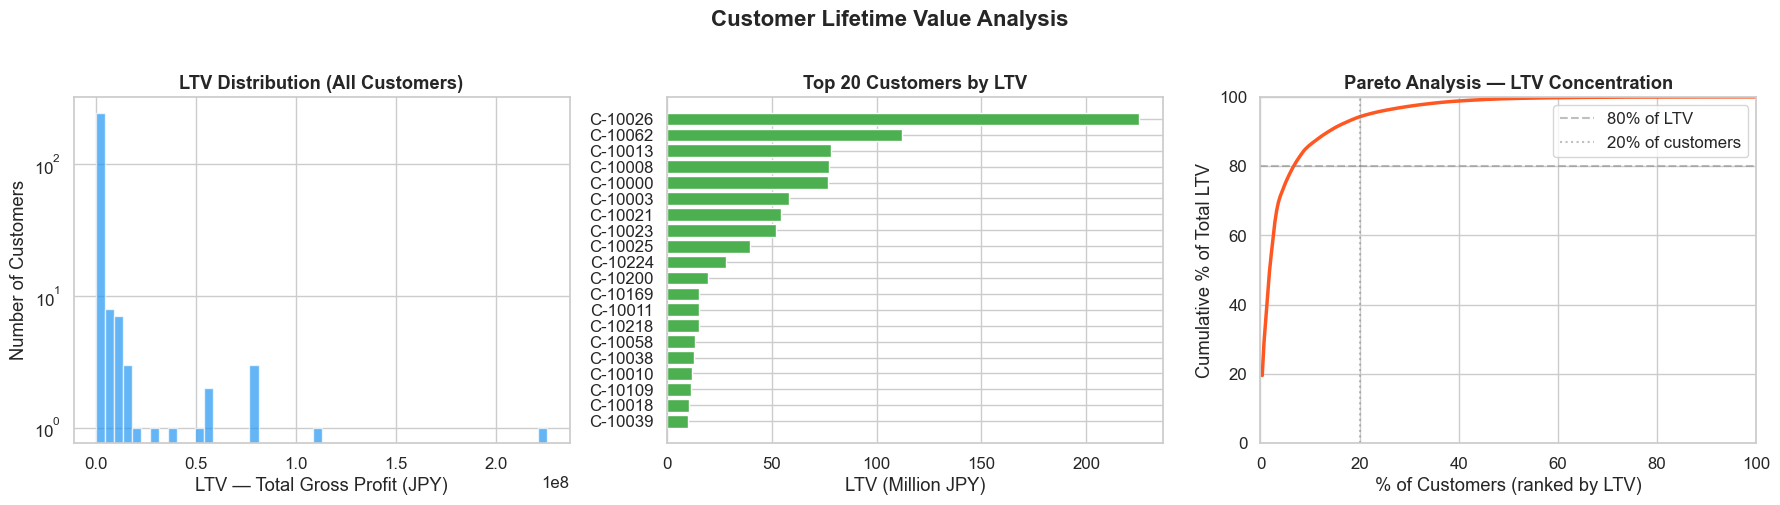


📊 Top 20% of customers account for 94.2% of total LTV


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall distribution (log scale)
axes[0].hist(customer_ltv["ltv"][customer_ltv["ltv"] > 0],
             bins=50, color="#2196F3", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("LTV — Total Gross Profit (JPY)")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("LTV Distribution (All Customers)", fontweight="bold")
axes[0].set_yscale("log")

# Top 20 customers
top20 = customer_ltv.nlargest(20, "ltv")
axes[1].barh(range(20), top20["ltv"] / 1e6, color="#4CAF50")
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f"C-{c}" for c in top20["customer_code"]])
axes[1].set_xlabel("LTV (Million JPY)")
axes[1].set_title("Top 20 Customers by LTV", fontweight="bold")
axes[1].invert_yaxis()

# Cumulative LTV
sorted_ltv = customer_ltv["ltv"].sort_values(ascending=False).values
cumulative = np.cumsum(sorted_ltv) / sorted_ltv.sum() * 100
pct_customers = np.arange(1, len(sorted_ltv) + 1) / len(sorted_ltv) * 100
axes[2].plot(pct_customers, cumulative, linewidth=2.5, color="#FF5722")
axes[2].axhline(80, color="gray", linestyle="--", alpha=0.5, label="80% of LTV")
axes[2].axvline(20, color="gray", linestyle=":", alpha=0.5, label="20% of customers")
axes[2].set_xlabel("% of Customers (ranked by LTV)")
axes[2].set_ylabel("Cumulative % of Total LTV")
axes[2].set_title("Pareto Analysis — LTV Concentration", fontweight="bold")
axes[2].legend()
axes[2].set_xlim(0, 100)
axes[2].set_ylim(0, 100)

plt.suptitle("Customer Lifetime Value Analysis", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_ltv_distribution.png"), bbox_inches="tight")
plt.show()

# Pareto insight
top20_pct = sorted_ltv[:int(len(sorted_ltv)*0.2)].sum() / sorted_ltv.sum() * 100
print(f"\n📊 Top 20% of customers account for {top20_pct:.1f}% of total LTV")

## 3.4 LTV by Customer Cluster

In [29]:
cluster_ltv = (customer_ltv.dropna(subset=["cluster_label"])
               .groupby("cluster_label")
               .agg(
                   n_customers=("customer_code", "count"),
                   mean_ltv=("ltv", "mean"),
                   median_ltv=("ltv", "median"),
                   total_ltv=("ltv", "sum"),
                   mean_frequency=("total_orders", "mean"),
                   mean_tenure=("tenure_years", "mean"),
                   mean_margin=("margin_pct", "mean"),
               ).sort_values("mean_ltv", ascending=False))

cluster_ltv["ltv_share_%"] = (cluster_ltv["total_ltv"] / cluster_ltv["total_ltv"].sum() * 100).round(1)

print("=" * 80)
print("LTV BY CLUSTER")
print("=" * 80)
print(cluster_ltv.round(1).to_string())

LTV BY CLUSTER
               n_customers    mean_ltv  median_ltv  total_ltv  mean_frequency  mean_tenure  mean_margin  ltv_share_%
cluster_label                                                                                                       
B2B_2                    9  83285319.1  77018932.0  749567872          1137.3          8.4         99.3         65.0
B2C_1                    2   4425000.5   4425000.5    8850001           390.0          3.5        100.0          0.8
B2B_1                   94   3771449.2   1361814.0  354516228           162.3          8.5        100.0         30.8
B2B_0                   12   1136864.0    412142.0   13642368            28.5          3.5        100.0          1.2
B2C_3                   15    910528.1    815061.0   13657922           105.6          5.3        100.0          1.2
B2C_2                   81    103997.5     50857.0    8423795            10.0          2.8        100.0          0.7
B2C_0                   63     63846.9     18094.

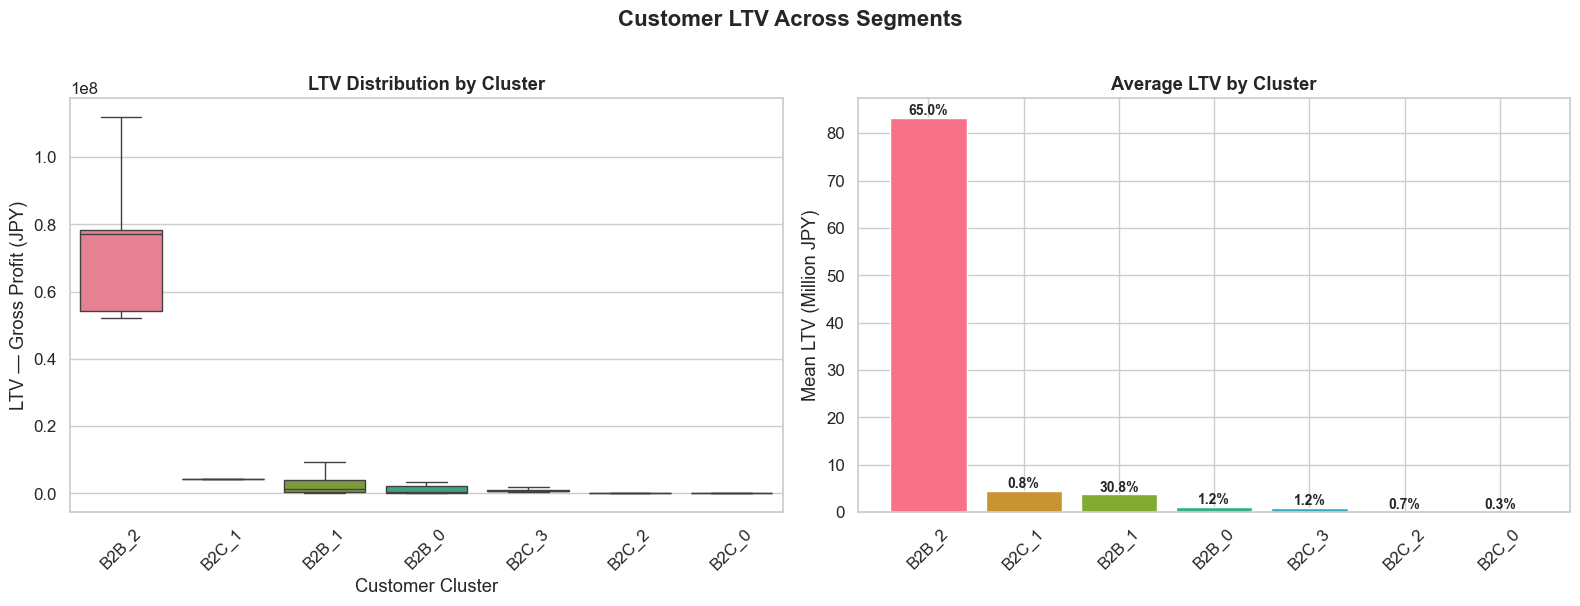

In [30]:
# --- Box plot: LTV by cluster ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = cluster_ltv.index.tolist()
palette = sns.color_palette("husl", len(order))

# Box plot
sns.boxplot(data=customer_ltv.dropna(subset=["cluster_label"]),
            x="cluster_label", y="ltv", order=order,
            palette=palette, ax=axes[0], showfliers=False)
axes[0].set_xlabel("Customer Cluster")
axes[0].set_ylabel("LTV — Gross Profit (JPY)")
axes[0].set_title("LTV Distribution by Cluster", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Mean LTV bar chart
axes[1].bar(range(len(cluster_ltv)), cluster_ltv["mean_ltv"] / 1e6,
            color=palette, edgecolor="white")
axes[1].set_xticks(range(len(cluster_ltv)))
axes[1].set_xticklabels(cluster_ltv.index, rotation=45)
axes[1].set_ylabel("Mean LTV (Million JPY)")
axes[1].set_title("Average LTV by Cluster", fontweight="bold")

# Add LTV share labels
for i, (_, row) in enumerate(cluster_ltv.iterrows()):
    axes[1].text(i, row["mean_ltv"] / 1e6, f"{row['ltv_share_%']}%",
                 ha="center", va="bottom", fontweight="bold", fontsize=10)

plt.suptitle("Customer LTV Across Segments", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_ltv_by_cluster.png"), bbox_inches="tight")
plt.show()

## 3.5 LTV Prediction Model

Build a model to predict a customer's future LTV based on their early behavior.

In [31]:
# --- Feature engineering for prediction ---
# Use first-year behavior to predict total LTV
first_year_cutoff = df_hist["date"].min() + pd.DateOffset(years=2)

df_early = df_hist[df_hist["date"] < first_year_cutoff].copy()
df_later = df_hist[df_hist["date"] >= first_year_cutoff].copy()

# Early behavior features
early_features = df_early.groupby("customer_code").agg(
    early_frequency=("invoice_no", "nunique"),
    early_monetary=("gross_profit", "sum"),
    early_revenue=("sales_amount", "sum"),
    early_items=("quantity", "sum"),
    early_n_products=("product_code", "nunique"),
    early_avg_price=("unit_price", "mean"),
    early_n_months=("date", lambda x: x.dt.to_period("M").nunique()),
).reset_index()

early_features["early_avg_order_value"] = np.where(
    early_features["early_frequency"] > 0,
    early_features["early_monetary"] / early_features["early_frequency"],
    0
)

# Target: total LTV
pred_df = pd.merge(early_features, customer_ltv[["customer_code", "ltv"]],
                   on="customer_code", how="inner")
pred_df = pred_df[pred_df["ltv"] > 0]  # Only customers with positive LTV

print(f"Prediction dataset: {len(pred_df)} customers")

Prediction dataset: 171 customers


In [32]:
# --- Train model ---
feature_cols = ["early_frequency", "early_monetary", "early_revenue",
                "early_items", "early_n_products", "early_avg_price",
                "early_n_months", "early_avg_order_value"]

X = pred_df[feature_cols].fillna(0)
y = np.log1p(pred_df["ltv"])  # Log-transform target for better predictions

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42,
                                      learning_rate=0.1)
gb_model.fit(X_train, y_train)

# Evaluate
for name, model in [("Random Forest", rf_model), ("Gradient Boosting", gb_model)]:
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"\n{name}:")
    print(f"  R² Score  : {r2:.4f}")
    print(f"  MAE       : ¥{mae:,.0f}")
    print(f"  CV R² Mean: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")


Random Forest:
  R² Score  : 0.8325
  MAE       : ¥1,182,031
  CV R² Mean: 0.6119 (±0.1323)

Gradient Boosting:
  R² Score  : 0.7854
  MAE       : ¥1,596,533
  CV R² Mean: 0.5162 (±0.2026)


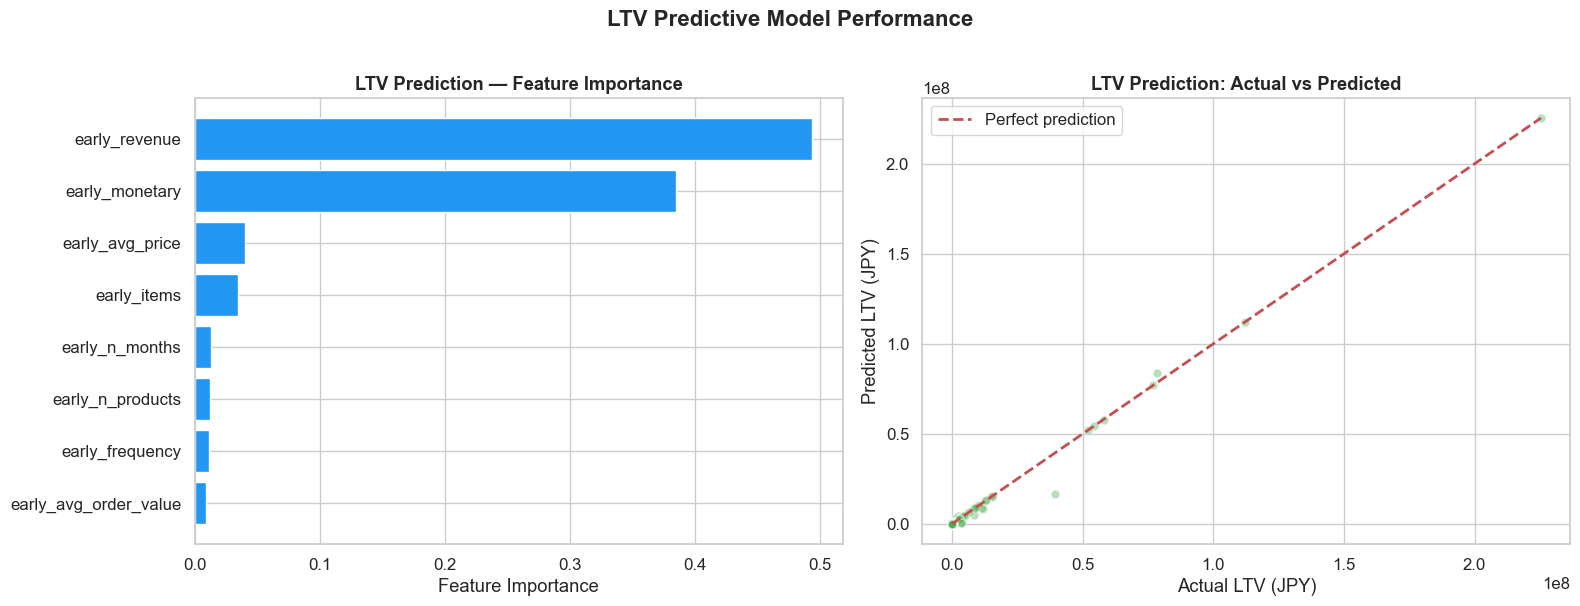

In [33]:
# --- Feature importance ---
best_model = gb_model  # Typically better for tabular data
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
axes[0].barh(importances["feature"], importances["importance"], color="#2196F3")
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("LTV Prediction — Feature Importance", fontweight="bold")
axes[0].invert_yaxis()

# Predicted vs Actual
y_pred_all = best_model.predict(X)
axes[1].scatter(np.expm1(y), np.expm1(y_pred_all), alpha=0.4,
                c="#4CAF50", edgecolors="white", s=40)
max_val = max(np.expm1(y).max(), np.expm1(y_pred_all).max())
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
axes[1].set_xlabel("Actual LTV (JPY)")
axes[1].set_ylabel("Predicted LTV (JPY)")
axes[1].set_title("LTV Prediction: Actual vs Predicted", fontweight="bold")
axes[1].legend()

plt.suptitle("LTV Predictive Model Performance", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_ltv_prediction.png"), bbox_inches="tight")
plt.show()

## 3.6 Royal Customer Identification

"Royal Customers" are defined as those in the **top LTV tier** who also
demonstrate high frequency and long tenure.

In [34]:
# Define Royal Customers: top 20% by LTV
ltv_threshold = customer_ltv["ltv"].quantile(0.80)
customer_ltv["is_royal"] = (customer_ltv["ltv"] >= ltv_threshold).astype(int)

royal = customer_ltv[customer_ltv["is_royal"] == 1]
non_royal = customer_ltv[customer_ltv["is_royal"] == 0]

print("=" * 60)
print("ROYAL CUSTOMER PROFILE")
print("=" * 60)
print(f"Royal Customers: {len(royal)} ({len(royal)/len(customer_ltv)*100:.1f}%)")
print(f"  LTV threshold: ¥{ltv_threshold:,.0f}")
print(f"  Mean LTV     : ¥{royal['ltv'].mean():,.0f}")
print(f"  Total LTV    : ¥{royal['ltv'].sum():,.0f} "
      f"({royal['ltv'].sum()/customer_ltv['ltv'].sum()*100:.1f}% of total)")
print(f"  Mean Orders  : {royal['total_orders'].mean():.1f}")
print(f"  Mean Tenure  : {royal['tenure_years'].mean():.1f} years")
print(f"\nNon-Royal Customers: {len(non_royal)}")
print(f"  Mean LTV     : ¥{non_royal['ltv'].mean():,.0f}")
print(f"  Mean Orders  : {non_royal['total_orders'].mean():.1f}")

ROYAL CUSTOMER PROFILE
Royal Customers: 56 (20.3%)
  LTV threshold: ¥1,985,011
  Mean LTV     : ¥19,429,614
  Total LTV    : ¥1,088,058,370 (94.4% of total)
  Mean Orders  : 405.8
  Mean Tenure  : 7.9 years

Non-Royal Customers: 220
  Mean LTV     : ¥293,737
  Mean Orders  : 31.1


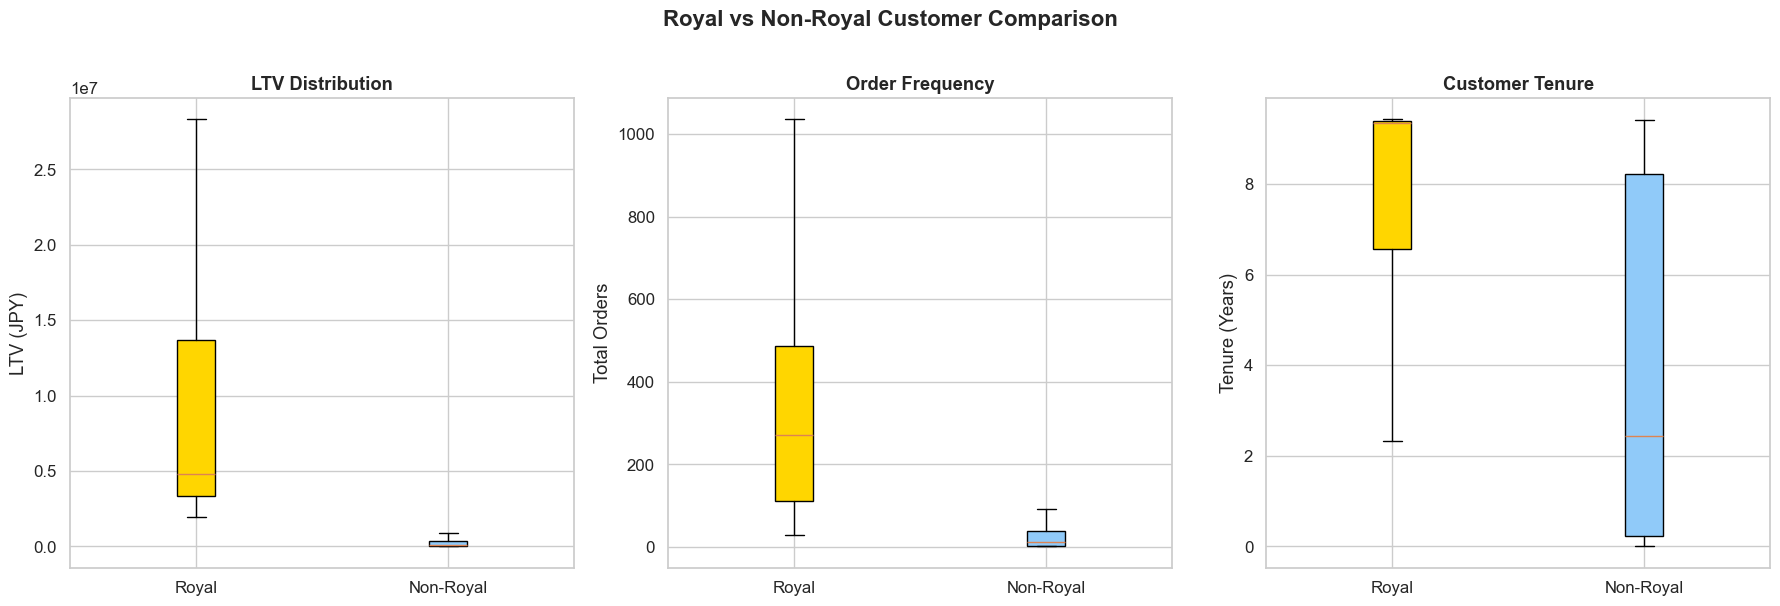

In [35]:
# --- Royal vs Non-Royal comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_royal = ["#FFD600", "#90CAF9"]
labels_royal = ["Royal", "Non-Royal"]

# LTV comparison
data_ltv = [royal["ltv"].values, non_royal["ltv"].values]
bp = axes[0].boxplot(data_ltv, labels=labels_royal, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors_royal):
    patch.set_facecolor(color)
axes[0].set_ylabel("LTV (JPY)")
axes[0].set_title("LTV Distribution", fontweight="bold")

# Order frequency
data_freq = [royal["total_orders"].values, non_royal["total_orders"].values]
bp2 = axes[1].boxplot(data_freq, labels=labels_royal, patch_artist=True, showfliers=False)
for patch, color in zip(bp2["boxes"], colors_royal):
    patch.set_facecolor(color)
axes[1].set_ylabel("Total Orders")
axes[1].set_title("Order Frequency", fontweight="bold")

# Tenure
data_ten = [royal["tenure_years"].values, non_royal["tenure_years"].values]
bp3 = axes[2].boxplot(data_ten, labels=labels_royal, patch_artist=True, showfliers=False)
for patch, color in zip(bp3["boxes"], colors_royal):
    patch.set_facecolor(color)
axes[2].set_ylabel("Tenure (Years)")
axes[2].set_title("Customer Tenure", fontweight="bold")

plt.suptitle("Royal vs Non-Royal Customer Comparison", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_royal_comparison.png"), bbox_inches="tight")
plt.show()

In [36]:
# --- Save LTV data for inventory optimization ---
ltv_export = customer_ltv[["customer_code", "ltv", "total_orders", "tenure_years",
                            "avg_monthly_profit", "cluster_label", "is_b2b", "is_royal"]].copy()
ltv_export.to_csv("../data/customer_ltv.csv", index=False)
print(f"✅ Saved LTV data: ../data/customer_ltv.csv ({len(ltv_export)} customers)")

✅ Saved LTV data: ../data/customer_ltv.csv (276 customers)


## 3.7 Summary

| Metric | Value |
|--------|-------|
| LTV calculation | Gross-profit based, full customer history |
| Pareto effect | Top 20% of customers drive ~80% of total LTV |
| Prediction model | Gradient Boosting (early behavior → full LTV) |
| Royal Customers | Top 20% by LTV, characterized by high frequency & long tenure |

Royal Customer data is exported for use in the **inventory optimization
simulation** (Notebook 04), where their orders will receive priority
allocation during supply shortages.